# XGBoost - PRE-TRAINING IKLIM (ERA5) Interval 1 Jam


In [1]:
# Sel 1: Impor Library dan Setup Lingkungan
import os
import sys
import json
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import optuna
import shap
import scipy.stats as stats

from pathlib import Path
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, auc, confusion_matrix,
    brier_score_loss, mean_squared_error, mean_absolute_error, r2_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger()
logger.info("Kerangka Pemodelan Prediksi Curah Hujan 1-Jam Dimulai...")



2026-07-01 13:57:09,051 - INFO - Kerangka Pemodelan Prediksi Curah Hujan 1-Jam Dimulai...


## Tahap 2: Konfigurasi Global & Konstanta

Sel ini mendefinisikan seluruh variabel kontrol untuk *pipeline*. Anda bisa mengganti mode berjalannya notebook (`RUN_MODE`) menjadi mode cepat (*fast-test*) atau mode penuh (*pipeline_test*), serta menentukan jumlah *trials* Optuna.

In [2]:
# Sel 2: Konfigurasi Global
# Mode eksekusi: 
# - "FULL_TRAIN": Untuk optimasi dan pelatihan menyeluruh
# - "PIPELINE_TEST": Untuk uji coba cepat di Lokal (data dipotong & uji coba dibatasi)
RUN_MODE = "FULL_TRAIN"  # Ubah ke "PIPELINE_TEST" untuk uji coba cepat
SEED = 281225

if RUN_MODE == "PIPELINE_TEST":
    OPTUNA_TRIALS = 5
    EPOCHS = 2
else:
    OPTUNA_TRIALS = 100
    EPOCHS = 100

BASE_OUTPUT_DIR = Path('outputs_xgboost')

import random
random.seed(SEED)
np.random.seed(SEED)
import tensorflow as tf
tf.random.set_seed(SEED)



2026-07-01 13:57:10.806020: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782914231.018666      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782914231.081784      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782914231.578001      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782914231.578048      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782914231.578051      24 computation_placer.cc:177] computation placer alr

## Tahap 3: Mesin Evaluasi Terpadu (*ModelEvaluator*)

Ini adalah mesin (*engine*) utama untuk melakukan pelaporan hasil model. Kelas ini bertanggung jawab menghitung semua metrik meteorologi (CSI, POD, FAR), metrik klasifikasi (ROC-AUC), metrik regresi (RMSE), serta menyimpan seluruh grafik evaluasi dan kurva kalibrasi secara otomatis ke folder `outputs_*/`.

In [3]:
# Sel 3: Mesin Evaluasi Terpadu (Unified Evaluation Engine)
class ModelEvaluator:
    def __init__(self):
        self.base_dir = BASE_OUTPUT_DIR
        self.dirs = {
            'models': self.base_dir / 'models',
            'models_clf': self.base_dir / 'models' / 'classifier',
            'models_reg': self.base_dir / 'models' / 'regressor',
            'models_cal': self.base_dir / 'models' / 'calibration',
            'metrics': self.base_dir / 'metrics',
            'reports': self.base_dir / 'reports',
            'plots': self.base_dir / 'plots',
        }
        
        for d in self.dirs.values():
            d.mkdir(parents=True, exist_ok=True)
            
    def calc_meteorological_metrics(self, y_true, y_pred):
        hits = np.sum((y_pred == 1) & (y_true == 1))
        misses = np.sum((y_pred == 0) & (y_true == 1))
        false_alarms = np.sum((y_pred == 1) & (y_true == 0))
        correct_negatives = np.sum((y_pred == 0) & (y_true == 0))
        
        total = len(y_true)
        hits_random = ((hits + misses) * (hits + false_alarms)) / (total + 1e-9)
        
        csi = hits / (hits + misses + false_alarms + 1e-9)
        pod = hits / (hits + misses + 1e-9)
        far = false_alarms / (hits + false_alarms + 1e-9)
        ets = (hits - hits_random) / (hits + misses + false_alarms - hits_random + 1e-9)
        hss = 2 * (hits * correct_negatives - misses * false_alarms) / ((hits + misses) * (misses + correct_negatives) + (hits + false_alarms) * (false_alarms + correct_negatives) + 1e-9)
        
        return {'CSI': float(csi), 'POD': float(pod), 'FAR': float(far), 'ETS': float(ets), 'HSS': float(hss)}

    def calc_hydrological_metrics(self, y_true, y_pred):
        if len(y_true) < 2: return {'NSE': 0.0, 'KGE': 0.0, 'Correlation': 0.0}
        mean_obs, mean_sim = np.mean(y_true), np.mean(y_pred)
        std_obs, std_sim = np.std(y_true), np.std(y_pred)
        
        numerator = np.sum((y_true - y_pred)**2)
        denominator = np.sum((y_true - mean_obs)**2)
        nse = 1 - (numerator / (denominator + 1e-9))
        
        if std_obs > 0 and std_sim > 0:
            r = np.corrcoef(y_true, y_pred)[0, 1]
            beta = mean_sim / (mean_obs + 1e-9)
            gamma = (std_sim / mean_sim) / (std_obs / mean_obs + 1e-9) if mean_sim > 0 else 0
            kge = 1 - np.sqrt((r - 1)**2 + (beta - 1)**2 + (gamma - 1)**2)
        else:
            r, kge = 0.0, 0.0
            
        return {'NSE': float(nse), 'KGE': float(kge), 'Correlation': float(r)}

    def evaluate_classification(self, y_true, y_prob_uncal, y_prob_cal, y_pred):
        logger.info("Menghitung metrik klasifikasi...")
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        roc_auc = roc_auc_score(y_true, y_prob_cal)
        
        brier_uncal = brier_score_loss(y_true, y_prob_uncal)
        brier_cal = brier_score_loss(y_true, y_prob_cal)
        
        precision_arr, recall_arr, _ = precision_recall_curve(y_true, y_prob_cal)
        pr_auc = auc(recall_arr, precision_arr)
        
        metrics = {
            'Accuracy': float(acc), 
            'Precision': float(prec), 
            'Recall': float(rec), 
            'F1 Score': float(f1), 
            'ROC-AUC': float(roc_auc), 
            'PR-AUC': float(pr_auc), 
            'Brier Score (Uncalibrated)': float(brier_uncal), 'Brier Score (Calibrated)': float(brier_cal)
        }
        
        with open(self.dirs['metrics'] / 'classification_metrics.json', 'w') as f:
            json.dump(metrics, f, indent=4)
            
        meteo_metrics = self.calc_meteorological_metrics(y_true, y_pred)
        with open(self.dirs['metrics'] / 'meteorological_metrics.json', 'w') as f:
            json.dump(meteo_metrics, f, indent=4)
            
        
        self.plot_calibration_curve(y_true, y_prob_uncal, y_prob_cal)
        self.plot_reliability_diagram(y_true, y_prob_uncal, y_prob_cal)
        self.plot_probability_distribution(y_prob_cal)
        self.plot_roc_curve(y_true, y_prob_cal)
        self.plot_precision_recall_curve(y_true, y_prob_cal)
        self.plot_threshold_analysis(y_true, y_prob_cal)
        
        
        self.plot_prediction_vs_observation(y_true, y_pred)
        self.plot_error_distribution(y_true, y_pred)
        residuals = y_true - y_pred
        self.plot_residual_distribution(residuals)
        self.plot_qq_plot(residuals)
        self.plot_rainfall_event_comparison(y_true, y_pred)
        
        return metrics, meteo_metrics

    def evaluate_regression(self, y_true, y_pred):
        logger.info("Menghitung metrik regresi...")
        if len(y_true) == 0: return {}
        
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        bias = np.mean(y_pred - y_true)
        
        hydro = self.calc_hydrological_metrics(y_true, y_pred)
        
        metrics = {'RMSE': float(rmse), 'MAE': float(mae), 'R2': float(r2), 'Bias': float(bias)}
        metrics.update(hydro)
        
        with open(self.dirs['metrics'] / 'regression_metrics.json', 'w') as f:
            json.dump(metrics, f, indent=4)
        
        self.plot_prediction_vs_observation(y_true, y_pred)
        self.plot_error_distribution(y_true, y_pred)
        residuals = y_true - y_pred
        self.plot_residual_distribution(residuals)
        self.plot_qq_plot(residuals)
        self.plot_rainfall_event_comparison(y_true, y_pred)
        
        return metrics

    # --- 01_probability plots ---
    def plot_reliability_diagram(self, y_true, y_prob_uncal, y_prob_cal):
        plt.figure(figsize=(8,6))
        if y_prob_cal is not None:
            prob_true_c, prob_pred_c = calibration_curve(y_true, y_prob_cal, n_bins=10)
            plt.plot(prob_pred_c, prob_true_c, marker='s', label='Calibrated')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.title('Reliability Diagram')
        plt.xlabel('Prediksi Probabilitas')
        plt.ylabel('Fraksi Positif Aktual')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'reliability_diagram.png')
        plt.show()

    def plot_probability_distribution(self, y_prob_cal):
        plt.figure(figsize=(8,6))
        sns.histplot(y_prob_cal, bins=20, kde=True, color='green', alpha=0.5)
        plt.title('Probability Distribution')
        plt.xlabel('Probabilitas Klasifikasi')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'probability_distribution.png')
        plt.show()

    def plot_calibration_curve(self, y_true, y_prob_uncal, y_prob_cal=None):
        plt.figure(figsize=(8,6))
        prob_true, prob_pred = calibration_curve(y_true, y_prob_uncal, n_bins=10)
        plt.plot(prob_pred, prob_true, marker='o', label='Uncalibrated Model', color='blue')
        if y_prob_cal is not None:
            prob_true_c, prob_pred_c = calibration_curve(y_true, y_prob_cal, n_bins=10)
            plt.plot(prob_pred_c, prob_true_c, marker='s', label='Calibrated Model', color='green')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.title('Calibration Curve (Uncalibrated vs Calibrated)')
        plt.xlabel('Prediksi Probabilitas')
        plt.ylabel('Kejadian Aktual')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'calibration_curve.png')
        plt.show()

    # --- 02_classification plots ---
    def plot_confusion_matrix(self, y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title('Confusion Matrix')
        plt.xlabel('Prediksi')
        plt.ylabel('Aktual')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'confusion_matrix.png')
        plt.show()
        
    def plot_roc_curve(self, y_true, y_prob):
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        plt.figure(figsize=(6,6))
        plt.plot(fpr, tpr, color='darkorange', lw=2)
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.title('ROC Curve')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'roc_curve.png')
        plt.show()

    def plot_precision_recall_curve(self, y_true, y_prob):
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        plt.figure(figsize=(6,6))
        plt.plot(recall, precision, color='purple', lw=2)
        plt.title('Precision-Recall Curve')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'precision_recall_curve.png')
        plt.show()

    def plot_threshold_analysis(self, y_true, y_prob):
        thresholds = np.linspace(0.1, 0.9, 50)
        f1_scores = [f1_score(y_true, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
        plt.figure(figsize=(8,5))
        plt.plot(thresholds, f1_scores, marker='x', color='blue')
        plt.title('Threshold Analysis (F1 Score)')
        plt.xlabel('Threshold')
        plt.ylabel('F1 Score')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'threshold_analysis.png')
        plt.show()

    # --- 03_regression plots ---
    def plot_prediction_vs_observation(self, y_true, y_pred):
        if len(y_true) == 0: return
        plt.figure(figsize=(8,8))
        plt.scatter(y_true, y_pred, alpha=0.5, color='teal')
        max_val = max(np.max(y_true), np.max(y_pred))
        plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')
        plt.title('Prediction vs Observation')
        plt.xlabel('Observasi (mm)')
        plt.ylabel('Prediksi (mm)')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'prediction_vs_observation.png')
        plt.show()

    def plot_residual_distribution(self, residuals):
        plt.figure(figsize=(8,6))
        sns.histplot(residuals, kde=True, color='crimson')
        plt.title('Residual Distribution')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'residual_distribution.png')
        plt.show()
        
    def plot_qq_plot(self, residuals):
        plt.figure(figsize=(6,6))
        stats.probplot(residuals, dist="norm", plot=plt)
        plt.title('QQ Plot of Residuals')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'qq_plot.png')
        plt.show()

    def plot_error_distribution(self, y_true, y_pred):
        abs_errors = np.abs(y_true - y_pred)
        plt.figure(figsize=(8,6))
        sns.boxplot(y=abs_errors, color='orange')
        plt.title('Error Distribution (Absolute)')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'error_distribution.png')
        plt.show()

    # --- 04_timeseries plots ---
    def plot_timeseries_prediction_vs_observation(self, y_true, y_pred, timestamps):
        plt.figure(figsize=(15, 5))
        plt.plot(timestamps, y_true, label='Observasi', color='blue', alpha=0.7)
        plt.plot(timestamps, y_pred, label='Prediksi', color='red', alpha=0.7)
        plt.title('Timeseries: Prediction vs Observation')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'timeseries_prediction_vs_observation.png')
        plt.show()

    def plot_rainfall_event_comparison(self, y_true, y_pred):
        plt.figure(figsize=(10, 5))
        idx = np.argsort(y_true)[::-1][:50] # Top 50 extreme events
        plt.bar(np.arange(len(idx)) - 0.2, np.array(y_true)[idx], width=0.4, label='Observasi')
        plt.bar(np.arange(len(idx)) + 0.2, np.array(y_pred)[idx], width=0.4, label='Prediksi')
        plt.title('Rainfall Event Comparison (Top 50)')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'rainfall_event_comparison.png')
        plt.show()

    def plot_cumulative_rainfall(self, y_true, y_pred, timestamps):
        plt.figure(figsize=(10, 6))
        plt.plot(timestamps, np.cumsum(y_true), label='Cumulative Observasi', color='blue')
        plt.plot(timestamps, np.cumsum(y_pred), label='Cumulative Prediksi', color='red')
        plt.title('Cumulative Rainfall')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'cumulative_rainfall.png')
        plt.show()

    # --- Laporan ---
    def generate_report(self, n_train, n_val, n_test, feature_names, clf_metrics, meteo_metrics, reg_metrics, algorithm_name):
        features_list = "\n".join([f"- {f}" for f in feature_names])
        
        report_content = f"""# Laporan Evaluasi Model Prediksi Curah Hujan 1 Jam
        
## Deskripsi Model
Framework ini membangun arsitektur dua tahap (*Two-Stage Model*) untuk memprediksi curah hujan akumulasi 1-jam.
Tahap pertama mengklasifikasikan kejadian hujan (P(Hujan) $\ge$ 1.0 mm), kemudian tahap kedua (regresi) menebak nilai intensitas untuk wilayah yang diklasifikasikan hujan.
**Algoritma Inti:** {algorithm_name}

## Jumlah Data
- **Jumlah Data Latih**: {n_train}
- **Jumlah Data Validasi**: {n_val}
- **Jumlah Data Uji**: {n_test}

## Daftar Variabel
{features_list}

## Hasil Klasifikasi
- Accuracy: {clf_metrics.get('Accuracy', 0):.4f}
- Precision: {clf_metrics.get('Precision', 0):.4f}
- Recall: {clf_metrics.get('Recall', 0):.4f}
- F1 Score: {clf_metrics.get('F1 Score', 0):.4f}
- ROC-AUC: {clf_metrics.get('ROC-AUC', 0):.4f}
- PR-AUC: {clf_metrics.get('PR-AUC', 0):.4f}
- Brier Score (Uncalibrated): {clf_metrics.get('Brier Score (Uncalibrated)', 0):.4f}
- Brier Score (Calibrated): {clf_metrics.get('Brier Score (Calibrated)', 0):.4f}

## Hasil Metrik Meteorologi
- CSI (Critical Success Index): {meteo_metrics.get('CSI', 0):.4f}
- POD (Probability of Detection): {meteo_metrics.get('POD', 0):.4f}
- FAR (False Alarm Ratio): {meteo_metrics.get('FAR', 0):.4f}
- ETS (Equitable Threat Score): {meteo_metrics.get('ETS', 0):.4f}
- HSS (Heidke Skill Score): {meteo_metrics.get('HSS', 0):.4f}

## Hasil Regresi
*(Dihitung eksklusif pada sampel aktual yang mengalami hujan)*
- RMSE (Root Mean Squared Error): {reg_metrics.get('RMSE', 0):.4f} mm
- MAE (Mean Absolute Error): {reg_metrics.get('MAE', 0):.4f} mm
- R² (Koefisien Determinasi): {reg_metrics.get('R2', 0):.4f}
- NSE (Nash-Sutcliffe Efficiency): {reg_metrics.get('NSE', 0):.4f}
- KGE (Kling-Gupta Efficiency): {reg_metrics.get('KGE', 0):.4f}
- Bias: {reg_metrics.get('Bias', 0):.4f}
- Correlation: {reg_metrics.get('Correlation', 0):.4f}

## Analisis Feature Importance
*Silakan merujuk ke folder `plots/` untuk melihat visualisasi SHAP dan diagram kepentingan fitur (Feature Importance) terhadap prediksi model.*

## Kesimpulan Performa Model
Berdasarkan nilai Brier Score, model mengalami perbaikan/penyesuaian keandalan probabilitas setelah kalibrasi Isotonic. 
Performa metrik meteorologi utama (CSI dan POD) menunjukkan akurasi model {algorithm_name} dalam menangkap fenomena presipitasi 1-jam ke depan.
"""
        with open(self.dirs['reports'] / 'summary_report_xgboost.md', 'w') as f:
            f.write(report_content)



## FASE 1: PRE-TRAINING (Data Satelit & ERA5)

**Tujuan:** Melatih model dasar menggunakan data historis berskala besar.
Sel ini bertugas menyatukan *dataset* ERA5 Standard dan ERA5 ML Features. Semua fitur utama (`temperature`, `humidity`, dll) **diambil sepenuhnya dari data proksi ERA5**.

In [4]:
# --- FASE PRE-TRAINING ---
# Sel 4: Pemuatan Data dan Penyatuan (Data Loading & Merge) untuk PRE-TRAINING
import os
from pathlib import Path
import pandas as pd
import numpy as np

logger.info("Mendeteksi Environment & Memuat data ERA5 untuk Pre-Training...")

if os.path.exists('/kaggle/input'):
    import glob
    search_file = glob.glob('/kaggle/input/**/ERA5_Land_Standard_Units_TimeSeries_UTC_WMO.csv', recursive=True)
    if search_file:
        SAT_DIR = Path(search_file[0]).parent
    else:
        SAT_DIR = Path('/kaggle/input/google-earth-engine-data/Google_Earth_Engine/Data_Satelit')
else:
    BASE_DATA_DIR = Path('D:/Github/Projek_Rainfall')
    SAT_DIR = BASE_DATA_DIR / 'Google_Earth_Engine' / 'Data_Satelit'

# 1. Memuat ERA5 Standard Units (ERA5-Land)
df_era5_std = pd.read_csv(SAT_DIR / 'ERA5_Land_Standard_Units_TimeSeries_UTC_WMO.csv')
df_era5_std['timestamp'] = pd.to_datetime(df_era5_std['datetime_utc'], utc=True).dt.tz_convert('Asia/Jakarta')
df_era5_std = df_era5_std.set_index('timestamp').sort_index()

# 2. Memuat ERA5 ML Features (ERA5)
df_era5_ml = pd.read_csv(SAT_DIR / 'ERA5_Hourly_All_Requested_Features_2000_2026.csv')
if 'datetime_utc' in df_era5_ml.columns:
    df_era5_ml['timestamp'] = pd.to_datetime(df_era5_ml['datetime_utc'], utc=True).dt.tz_convert('Asia/Jakarta')
else:
    df_era5_ml['timestamp'] = pd.to_datetime(df_era5_ml['unixtime'], unit='s', utc=True).dt.tz_convert('Asia/Jakarta')
df_era5_ml = df_era5_ml.set_index('timestamp').sort_index()

# Gabungkan kedua dataset ERA5
df_era5 = df_era5_std.join(df_era5_ml, how='inner', lsuffix='_std', rsuffix='_ml')

df_merged = df_era5.copy()

# Pemetaan Variabel Dasar
df_merged['temperature'] = df_merged['temperature_2m_C']
df_merged['humidity'] = df_merged['humidity_2m_pct']
df_merged['dewpoint'] = df_merged['dewpoint_temperature_2m_C']
df_merged['rainrate'] = df_merged['total_precipitation_hourly_mm']
df_merged['pressure'] = df_merged['surface_pressure_hPa']

# Fitur Angin ERA5
df_merged['era5_u_wind'] = df_merged['u_component_of_wind_10m_ms']
df_merged['era5_v_wind'] = df_merged['v_component_of_wind_10m_ms']

# Fitur ERA5 ML (Ekstraksi Fitur Konvektif Tambahan)
df_merged['era5_cape'] = df_merged['cape_era5']
df_merged['era5_tcwv'] = df_merged['total_column_water_vapour_era5']
df_merged['era5_k_index'] = df_merged['k_index_era5']
df_merged['era5_moisture_div'] = df_merged['moisture_divergence_era5']
df_merged['era5_total_totals'] = df_merged['total_totals_index_era5']
df_merged['era5_wind_gusts'] = df_merged['wind_gusts_era5']
df_merged['era5_direct_radiation'] = df_merged['direct_radiation_era5']
df_merged['era5_cloud_cover'] = df_merged['cloud_cover_era5']
df_merged['era5_soil_moisture'] = df_merged['soil_moisture_era5']
df_merged['era5_sunshine'] = df_merged['sunshine_duration_era5']

df_hourly = df_merged.dropna(subset=['temperature']).copy()
df_hourly = df_hourly.select_dtypes(include=[np.number])
logger.info(f"Dimensi data dasar terpadu (PRE-TRAINING): {df_hourly.shape}")


2026-07-01 13:57:23,198 - INFO - Mendeteksi Environment & Memuat data ERA5 untuk Pre-Training...
2026-07-01 13:57:26,090 - INFO - Dimensi data dasar terpadu (PRE-TRAINING): (231528, 49)


## Tahap 4: Rekayasa Fitur (*Feature Engineering*)

Sel ini meramu data mentah 1-jaman menjadi format 1-jaman yang siap ditelan model. Fitur-fitur canggih seperti **Tren 1 Jam** (*difference*) dihitung di sini, beserta nilai agregasi fitur konvektif tingkat lanjut (CAPE, K-Index) dari ERA5.

In [5]:
# Sel 5: Rekayasa Fitur Fisika Atmosfer
def engineer_features(df_base):
    logger.info("Mengekstraksi fitur fisika & temporal...")
    
    cols_diff = ['temperature', 'humidity', 'pressure']
    for c in cols_diff:
        if c in df_base.columns:
            df_base[f'{c}_tendency_1h'] = df_base[c].diff()
            
    if 'temperature' in df_base.columns and 'humidity' in df_base.columns:
        T = df_base['temperature']
        RH = df_base['humidity']
        e_s = 0.611 * np.exp((17.27 * T) / (T + 237.3))
        e_a = e_s * (RH / 100.0)
        df_base['vpd_kpa'] = e_s - e_a
        
    if 'temperature' in df_base.columns and 'dewpoint' in df_base.columns:
        df_base['dewpoint_depression'] = df_base['temperature'] - df_base['dewpoint']
        
    df_base['sin_hour'] = np.sin(2 * np.pi * df_base.index.hour / 24.0)
    df_base['cos_hour'] = np.cos(2 * np.pi * df_base.index.hour / 24.0)
    df_base['sin_month'] = np.sin(2 * np.pi * df_base.index.month / 12.0)
    df_base['cos_month'] = np.cos(2 * np.pi * df_base.index.month / 12.0)
    df_base['sin_doy'] = np.sin(2 * np.pi * df_base.index.dayofyear / 365.25)
    df_base['cos_doy'] = np.cos(2 * np.pi * df_base.index.dayofyear / 365.25)

    df = df_base.copy()
    
    if 'era5_u_wind' in df.columns and 'era5_v_wind' in df.columns and 'era5_wind_speed' not in df.columns:
        df['era5_wind_speed'] = np.sqrt(df['era5_u_wind']**2 + df['era5_v_wind']**2)

    df = df.dropna()
    logger.info(f"Dimensi akhir setelah rekayasa fitur: {df.shape}")
    return df


## Tahap 5: Pelatihan Klasifikasi Hujan (Optuna)

Di sini model dilatih untuk mengenali apakah curah hujan akan mencapai ambang batas (>= 1.0 mm) atau tidak. Sistem menggunakan algoritma pencarian cerdas **Optuna** untuk mencari kombinasi parameter terbaik.

2026-07-01 13:57:26,413 - INFO - 
MEMULAI OPTIMASI XGBOOST 3-JAM
2026-07-01 13:57:26,415 - INFO - Mengekstraksi fitur fisika & temporal...
2026-07-01 13:57:26,706 - INFO - Dimensi akhir setelah rekayasa fitur: (231506, 61)
2026-07-01 13:57:26,854 - INFO - Distribusi Split - Train: 174563, Val: 8754, Test: 8737
[I 2026-07-01 13:57:26,855] A new study created in memory with name: no-name-ba85c095-3185-4bc1-beeb-63a57ae90889
[I 2026-07-01 13:57:31,429] Trial 0 finished with value: 0.051822029219393655 and parameters: {'max_depth': 7, 'learning_rate': 0.059219579331272296, 'n_estimators': 116, 'subsample': 0.6967053744971726, 'colsample_bytree': 0.6204242425712966, 'gamma': 0.3410308858593386, 'min_child_weight': 2}. Best is trial 0 with value: 0.051822029219393655.
[I 2026-07-01 13:57:33,843] Trial 1 finished with value: 0.10192379264224803 and parameters: {'max_depth': 5, 'learning_rate': 0.002336994743914725, 'n_estimators': 79, 'subsample': 0.9390614384519077, 'colsample_bytree': 0.789

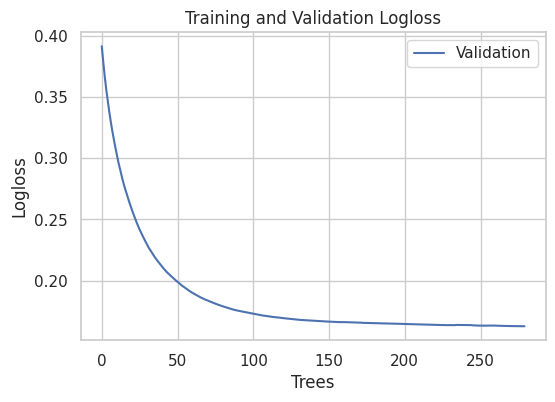

2026-07-01 14:14:28,410 - INFO - Plotly/Kaleido tidak tersedia, melewatkan optimization_history grafis optuna.


['outputs_xgboost/models/calibration/isotonic_calibrator.pkl']

In [6]:
# Sel 6: Setup & XGBoost Classifier Optuna
import xgboost as xgb

logger.info(f"\n{'='*50}\nMEMULAI OPTIMASI XGBOOST 3-JAM\n{'='*50}")
evaluator = ModelEvaluator()

# 1. Feature Engineering
df_features = engineer_features(df_hourly)

# 2. Target Creation (Prediksi 1 jam ke depan)
df_features['target_amount'] = df_features['rainrate'].shift(-1)
df_features = df_features.dropna()
df_features['target_occurrence'] = (df_features['target_amount'] >= 0.5).astype(int)

# 3. Data Split
if RUN_MODE == "PIPELINE_TEST":
    n = len(df_features)
    train_mask = np.arange(n) < int(n * 0.5)
    val_mask = (np.arange(n) >= int(n * 0.5)) & (np.arange(n) < int(n * 0.8))
    test_mask = np.arange(n) >= int(n * 0.8)
else:
# [PEMBAGIAN DATA PRE-TRAINING BERDASARKAN TANGGAL]
# Train : 31 Jan 2004 - Akhir 2023 (Menyesuaikan ketersediaan data Satelit Oya)
    train_mask = (df_features.index >= '2004-01-31') & (df_features.index <= '2023-12-31')
# Val   : Sepanjang Tahun 2024
    val_mask = (df_features.index >= '2024-01-01') & (df_features.index <= '2024-12-31')
# Test  : Sepanjang Tahun 2025
    test_mask = (df_features.index >= '2025-01-01') & (df_features.index <= '2025-12-31')

X = df_features.drop(columns=['target_amount', 'target_occurrence'])
y_occ = df_features['target_occurrence']
y_reg = df_features['target_amount']

X_train, y_train_occ, y_train_reg = X[train_mask], y_occ[train_mask], y_reg[train_mask]
X_val, y_val_occ, y_val_reg = X[val_mask], y_occ[val_mask], y_reg[val_mask]
X_test, y_test_occ, y_test_reg = X[test_mask], y_occ[test_mask], y_reg[test_mask]

logger.info(f"Distribusi Split - Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# --- STAGE 1: CLASSIFIER OPTIMIZATION ---
def objective_occ(trial):
    params = {
        'objective': 'binary:logistic', 'eval_metric': 'logloss',
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': SEED, 'tree_method': 'hist', 'device': 'cpu'
    }
    clf = xgb.XGBClassifier(**params)
    clf.fit(X_train, y_train_occ, eval_set=[(X_val, y_val_occ)], verbose=False)
    val_prob = clf.predict_proba(X_val)[:, 1]
    return brier_score_loss(y_val_occ, val_prob)

optuna.logging.set_verbosity(optuna.logging.INFO)
study_occ = optuna.create_study(direction='minimize')
study_occ.optimize(objective_occ, n_trials=OPTUNA_TRIALS)

# Melatih Classifier Terbaik
best_params_occ = study_occ.best_params
best_params_occ.update({'random_state': SEED, 'tree_method': 'hist', 'device': 'cpu'})
clf_best = xgb.XGBClassifier(**best_params_occ)
clf_best.fit(X_train, y_train_occ, eval_set=[(X_val, y_val_occ)], verbose=False)

# Evaluasi Kurva Loss Classifier
results_clf = clf_best.evals_result()
plt.figure(figsize=(6,4))
plt.plot(results_clf['validation_0']['logloss'], label='Validation')
plt.title('Training and Validation Logloss')
plt.ylabel('Logloss')
plt.xlabel('Trees')
plt.legend()
plt.savefig(evaluator.dirs['plots'] / 'validation_logloss.png')
plt.show()

# Plot Optimization History Optuna
try:
    fig = optuna.visualization.plot_optimization_history(study_occ)
    fig.write_image(str(evaluator.dirs['plots'] / 'optimization_history.png'))
except:
    logger.info("Plotly/Kaleido tidak tersedia, melewatkan optimization_history grafis optuna.")

joblib.dump(clf_best, evaluator.dirs['models_clf'] / 'best_xgb_occ.pkl')

# Probability Calibration (Isotonic Regression)
iso_reg = IsotonicRegression(out_of_bounds='clip')
val_probs_uncal = clf_best.predict_proba(X_val)[:, 1]
iso_reg.fit(val_probs_uncal, y_val_occ)
joblib.dump(iso_reg, evaluator.dirs['models_cal'] / 'isotonic_calibrator.pkl')


## Tahap 6: Pelatihan Regresi Intensitas (Optuna)

Setelah model tahu bahwa akan turun hujan, model *Regressor* ini bertugas menebak **Berapa lebat hujannya?** (dalam satuan milimeter). Hanya wilayah dengan probabilitas hujan tinggi yang dilatih di tahap ini.

[I 2026-07-01 14:14:28,528] A new study created in memory with name: no-name-d160e1e5-bc6b-46d7-9f64-67f46b12ac2f
[I 2026-07-01 14:14:31,107] Trial 0 finished with value: 3.091801288549716 and parameters: {'max_depth': 8, 'learning_rate': 0.010527081608543005, 'n_estimators': 108, 'subsample': 0.9419229791837104, 'colsample_bytree': 0.8835598554141024, 'gamma': 1.853184465142494, 'min_child_weight': 9}. Best is trial 0 with value: 3.091801288549716.
[I 2026-07-01 14:14:33,686] Trial 1 finished with value: 3.8013337276860804 and parameters: {'max_depth': 7, 'learning_rate': 0.004790039108114453, 'n_estimators': 176, 'subsample': 0.8185686273054906, 'colsample_bytree': 0.7185279250937976, 'gamma': 4.161442581670217, 'min_child_weight': 7}. Best is trial 0 with value: 3.091801288549716.
[I 2026-07-01 14:14:34,830] Trial 2 finished with value: 2.6584169792172996 and parameters: {'max_depth': 6, 'learning_rate': 0.017654635955835905, 'n_estimators': 93, 'subsample': 0.7144938147524598, 'col

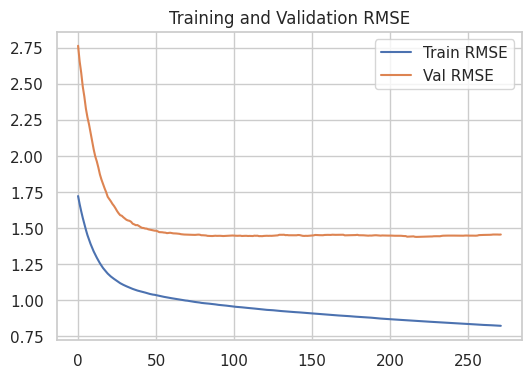

In [7]:
# Sel 7: XGBoost Regressor Optuna
# --- STAGE 2: REGRESSOR OPTIMIZATION ---
rainy_mask_train = y_train_occ == 1
rainy_mask_val = y_val_occ == 1
X_train_r, y_train_r = X_train[rainy_mask_train], y_train_reg[rainy_mask_train]
X_val_r, y_val_r = X_val[rainy_mask_val], y_val_reg[rainy_mask_val]

if np.sum(rainy_mask_train) > 10:
    def objective_reg(trial):
        params = {
            'objective': 'reg:squarederror', 'eval_metric': 'rmse',
            'max_depth': trial.suggest_int('max_depth', 3, 9),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'gamma': trial.suggest_float('gamma', 0.0, 5.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'random_state': SEED, 'tree_method': 'hist', 'device': 'cpu'
        }
        reg = xgb.XGBRegressor(**params)
        reg.fit(X_train_r, y_train_r, eval_set=[(X_val_r, y_val_r)], verbose=False)
        preds = reg.predict(X_val_r)
        return mean_squared_error(y_val_r, preds)
        
    study_reg = optuna.create_study(direction='minimize')
    study_reg.optimize(objective_reg, n_trials=OPTUNA_TRIALS)
    
    best_params_reg = study_reg.best_params
    best_params_reg.update({'random_state': SEED, 'tree_method': 'hist', 'device': 'cpu'})
    reg_best = xgb.XGBRegressor(**best_params_reg)
    reg_best.fit(X_train_r, y_train_r, eval_set=[(X_train_r, y_train_r), (X_val_r, y_val_r)], verbose=False)
    joblib.dump(reg_best, evaluator.dirs['models_reg'] / 'best_xgb_reg.pkl')
    
    # RMSE Curves
    results_reg = reg_best.evals_result()
    plt.figure(figsize=(6,4))
    plt.plot(results_reg['validation_0']['rmse'], label='Train RMSE')
    plt.plot(results_reg['validation_1']['rmse'], label='Val RMSE')
    plt.title('Training and Validation RMSE')
    plt.legend()
    plt.savefig(evaluator.dirs['plots'] / 'validation_rmse.png')
    plt.savefig(evaluator.dirs['plots'] / 'training_rmse.png')
    plt.show()
else:
    logger.warning("Tidak cukup sampel hujan untuk melatih Regressor.")
    reg_best = None

## FASE 2: FINE-TUNING (Data Aktual Stasiun AWS)

**Tujuan:** Menyelaraskan model dengan kondisi iklim lokal.
Sel ini menukar sumber data dasar menjadi **data pengukuran asli dari Stasiun AWS**, sembari mempertahankan fitur Angin dan Konvektif yang dipinjam secara dinamis dari ERA5.

In [8]:
# --- FASE FINE-TUNING ---
# Pemuatan Data dan Penyatuan (Data Loading & Merge)
import os
from pathlib import Path
import pandas as pd
import numpy as np

logger.info("Mendeteksi Environment & Memuat data stasional dan satelit...")

if os.path.exists('/kaggle/input'):
    import glob
    search_file = glob.glob('/kaggle/input/**/id-05_clear_data_hourly.csv', recursive=True)
    if search_file:
        STATION_FILE = Path(search_file[0])
        sat_search = glob.glob('/kaggle/input/**/ERA5_Land_Standard_Units_TimeSeries_UTC_WMO.csv', recursive=True)
        if sat_search:
            SAT_DIR = Path(sat_search[0]).parent
        else:
            SAT_DIR = Path('/kaggle/input/google-earth-engine-data/Google_Earth_Engine/Data_Satelit')
    else:
        STATION_FILE = Path('/kaggle/input/google-earth-engine-data/Google_Earth_Engine/Data_Stasiun/id-05_clear_data_hourly.csv')
        SAT_DIR = Path('/kaggle/input/google-earth-engine-data/Google_Earth_Engine/Data_Satelit')
else:
    BASE_DATA_DIR = Path('D:/Github/Projek_Rainfall')
    STATION_FILE = BASE_DATA_DIR / 'Google_Earth_Engine' /'Data_Satelit'/ 'id-05_clear_data_hourly.csv'
    SAT_DIR = BASE_DATA_DIR / 'Google_Earth_Engine' / 'Data_Satelit'

# 1. Memuat Data Stasiun AWS Lokal
df_station = pd.read_csv(STATION_FILE)
df_station['timestamp'] = pd.to_datetime(df_station['datetime_local'], utc=True).dt.tz_convert('Asia/Jakarta')
df_station = df_station.set_index('timestamp').sort_index()
# Hanya ambil kolom yang relevan dari AWS
cols_to_keep = ['temperature', 'humidity', 'pressure', 'dewpoint', 'rainrate']
df_station = df_station[cols_to_keep]

# 2. Memuat ERA5 (Identik dengan Pretraining)
df_era5_std = pd.read_csv(SAT_DIR / 'ERA5_Land_Standard_Units_TimeSeries_UTC_WMO.csv')
df_era5_std['timestamp'] = pd.to_datetime(df_era5_std['datetime_utc'], utc=True).dt.tz_convert('Asia/Jakarta')
df_era5_std = df_era5_std.set_index('timestamp').sort_index()

df_era5_ml = pd.read_csv(SAT_DIR / 'ERA5_Hourly_All_Requested_Features_2000_2026.csv')
if 'datetime_utc' in df_era5_ml.columns:
    df_era5_ml['timestamp'] = pd.to_datetime(df_era5_ml['datetime_utc'], utc=True).dt.tz_convert('Asia/Jakarta')
else:
    df_era5_ml['timestamp'] = pd.to_datetime(df_era5_ml['unixtime'], unit='s', utc=True).dt.tz_convert('Asia/Jakarta')
df_era5_ml = df_era5_ml.set_index('timestamp').sort_index()

df_era5 = df_era5_std.join(df_era5_ml, how='inner', lsuffix='_std', rsuffix='_ml')

df_merged = df_era5.copy()

# Pemetaan Variabel ERA5 Dasar
df_merged['temperature'] = df_merged['temperature_2m_C']
df_merged['humidity'] = df_merged['humidity_2m_pct']
df_merged['dewpoint'] = df_merged['dewpoint_temperature_2m_C']
df_merged['rainrate'] = df_merged['total_precipitation_hourly_mm']
df_merged['pressure'] = df_merged['surface_pressure_hPa']

# [REPLACEMENT AWS]
# Gabungkan dengan AWS. Di mana AWS ada, timpa ERA5!
df_merged.update(df_station)

# Fitur Angin ERA5
df_merged['era5_u_wind'] = df_merged['u_component_of_wind_10m_ms']
df_merged['era5_v_wind'] = df_merged['v_component_of_wind_10m_ms']

# Fitur ERA5 ML (Ekstraksi Fitur Konvektif Tambahan)
df_merged['era5_cape'] = df_merged['cape_era5']
df_merged['era5_tcwv'] = df_merged['total_column_water_vapour_era5']
df_merged['era5_k_index'] = df_merged['k_index_era5']
df_merged['era5_moisture_div'] = df_merged['moisture_divergence_era5']
df_merged['era5_total_totals'] = df_merged['total_totals_index_era5']
df_merged['era5_wind_gusts'] = df_merged['wind_gusts_era5']
df_merged['era5_direct_radiation'] = df_merged['direct_radiation_era5']
df_merged['era5_cloud_cover'] = df_merged['cloud_cover_era5']
df_merged['era5_soil_moisture'] = df_merged['soil_moisture_era5']
df_merged['era5_sunshine'] = df_merged['sunshine_duration_era5']

# Potong dataset mulai 2025 (mencakup 2025 dan 2026)
df_merged = df_merged[df_merged.index >= '2025-01-01']

df_hourly = df_merged.dropna(subset=['temperature']).copy()
df_hourly = df_hourly.select_dtypes(include=[np.number])
logger.info(f"Dimensi data terpadu (FINE-TUNING): {df_hourly.shape}")


2026-07-01 14:18:08,427 - INFO - Mendeteksi Environment & Memuat data stasional dan satelit...
2026-07-01 14:18:10,398 - INFO - Dimensi data terpadu (FINE-TUNING): (12367, 49)


## Inspeksi Data Fine-Tuning

Menampilkan struktur data, jumlah kolom, dan kelengkapan (*missing values*) dari data terpadu AWS sebelum masuk ke tahap *Feature Engineering*.

In [9]:
df_hourly.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12367 entries, 2025-01-01 00:00:00+07:00 to 2026-05-31 06:00:00+07:00
Data columns (total 49 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   unixtime_std                          12367 non-null  float64
 1   temperature_2m_C                      12367 non-null  float64
 2   dewpoint_temperature_2m_C             12367 non-null  float64
 3   humidity_2m_pct                       12367 non-null  float64
 4   u_component_of_wind_10m_ms            12367 non-null  float64
 5   v_component_of_wind_10m_ms            12367 non-null  float64
 6   surface_pressure_hPa                  12367 non-null  float64
 7   total_precipitation_hourly_mm         12367 non-null  float64
 8   unixtime_ml                           12367 non-null  float64
 9   temperature_era5                      12367 non-null  float64
 10  dewpoint_era5                      

## Tahap 4: Rekayasa Fitur (*Feature Engineering*)

Sel ini meramu data mentah 1-jaman menjadi format 1-jaman yang siap ditelan model. Fitur-fitur canggih seperti **Tren 1 Jam** (*difference*) dihitung di sini, beserta nilai agregasi fitur konvektif tingkat lanjut (CAPE, K-Index) dari ERA5.

In [10]:
# Sel 5: Rekayasa Fitur Fisika Atmosfer
def engineer_features(df_base):
    logger.info("Mengekstraksi fitur fisika & temporal...")
    
    cols_diff = ['temperature', 'humidity', 'pressure']
    for c in cols_diff:
        if c in df_base.columns:
            df_base[f'{c}_tendency_1h'] = df_base[c].diff()
            
    if 'temperature' in df_base.columns and 'humidity' in df_base.columns:
        T = df_base['temperature']
        RH = df_base['humidity']
        e_s = 0.611 * np.exp((17.27 * T) / (T + 237.3))
        e_a = e_s * (RH / 100.0)
        df_base['vpd_kpa'] = e_s - e_a
        
    if 'temperature' in df_base.columns and 'dewpoint' in df_base.columns:
        df_base['dewpoint_depression'] = df_base['temperature'] - df_base['dewpoint']
        
    df_base['sin_hour'] = np.sin(2 * np.pi * df_base.index.hour / 24.0)
    df_base['cos_hour'] = np.cos(2 * np.pi * df_base.index.hour / 24.0)
    df_base['sin_month'] = np.sin(2 * np.pi * df_base.index.month / 12.0)
    df_base['cos_month'] = np.cos(2 * np.pi * df_base.index.month / 12.0)
    df_base['sin_doy'] = np.sin(2 * np.pi * df_base.index.dayofyear / 365.25)
    df_base['cos_doy'] = np.cos(2 * np.pi * df_base.index.dayofyear / 365.25)

    df = df_base.copy()
    
    if 'era5_u_wind' in df.columns and 'era5_v_wind' in df.columns and 'era5_wind_speed' not in df.columns:
        df['era5_wind_speed'] = np.sqrt(df['era5_u_wind']**2 + df['era5_v_wind']**2)

    df = df.dropna()
    logger.info(f"Dimensi akhir setelah rekayasa fitur: {df.shape}")
    return df


In [11]:
# Ekstraksi Fitur dan Pembuatan Target untuk Fine-Tuning
df_features = engineer_features(df_hourly)

# Target Creation (Prediksi 1 jam ke depan, persis seperti pre-training)
df_features['target_amount'] = df_features['rainrate'].shift(-1)
df_features = df_features.dropna()
df_features['target_occurrence'] = (df_features['target_amount'] >= 0.5).astype(int)

# [PEMBAGIAN DATA FINE-TUNING BERDASARKAN TANGGAL]
# Train : 1 Jan 2025 - 31 Agustus 2025 (8 Bulan)
train_mask = (df_features.index >= '2025-01-01') & (df_features.index <= '2025-08-31')
# Val   : 1 September 2025 - 31 Desember 2025 (4 Bulan)
val_mask = (df_features.index >= '2025-09-01') & (df_features.index <= '2025-12-31')
# Test  : Dibuat sama dengan Validation (Bisa diubah jika ada data 2026)
test_mask = val_mask

X = df_features.drop(columns=['target_amount', 'target_occurrence'])
y_occ = df_features['target_occurrence']
y_reg = df_features['target_amount']

X_train, y_train_occ, y_train_reg = X[train_mask], y_occ[train_mask], y_reg[train_mask]
X_val, y_val_occ, y_val_reg = X[val_mask], y_occ[val_mask], y_reg[val_mask]
X_test, y_test_occ, y_test_reg = X[test_mask], y_occ[test_mask], y_reg[test_mask]

logger.info(f"Dimensi X_train (Fine-Tuning): {X_train.shape}")
logger.info(f"Dimensi X_val (Fine-Tuning): {X_val.shape}")
logger.info(f"Dimensi X_test (Fine-Tuning): {X_test.shape}")


2026-07-01 14:18:10,556 - INFO - Mengekstraksi fitur fisika & temporal...
2026-07-01 14:18:10,574 - INFO - Dimensi akhir setelah rekayasa fitur: (12366, 61)
2026-07-01 14:18:10,586 - INFO - Dimensi X_train (Fine-Tuning): (5808, 61)
2026-07-01 14:18:10,587 - INFO - Dimensi X_val (Fine-Tuning): (2905, 61)
2026-07-01 14:18:10,588 - INFO - Dimensi X_test (Fine-Tuning): (2905, 61)


## Tahap Terakhir: Proses Fine-Tuning & Perbandingan Model

Di tahap ini, model yang sudah pintar secara global di-*retrain* menggunakan dataset lokal (AWS). Sel ini juga mengaplikasikan **Isotonic Regression** untuk kalibrasi probabilitas, lalu menghasilkan laporan komparasi performa *Pre-trained* vs *Fine-tuned*.

2026-07-01 14:18:10,654 - INFO - Mengevaluasi Model Pre-Trained XGBoost pada Data Test AWS...
2026-07-01 14:18:10,679 - INFO - Memulai Fine-Tuning XGBoost Classifier...
2026-07-01 14:18:11,693 - INFO - Memulai Fine-Tuning XGBoost Regressor...
2026-07-01 14:18:11,958 - INFO - Menghitung metrik klasifikasi...


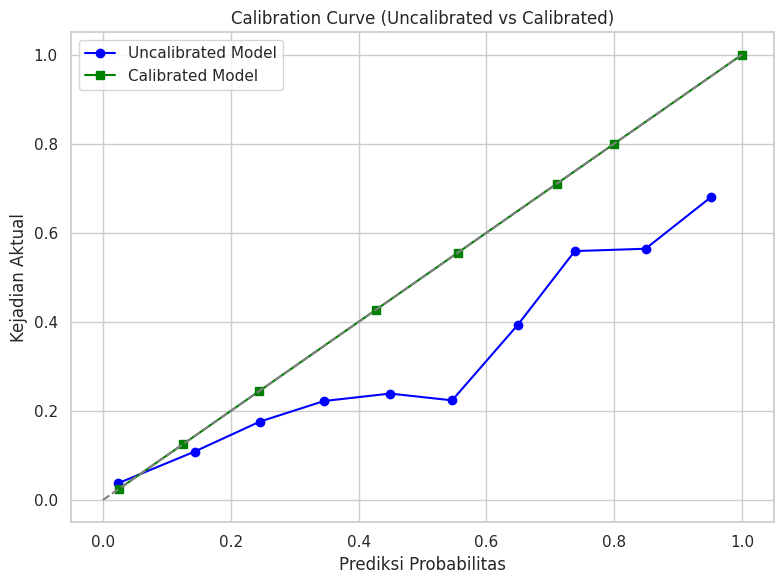

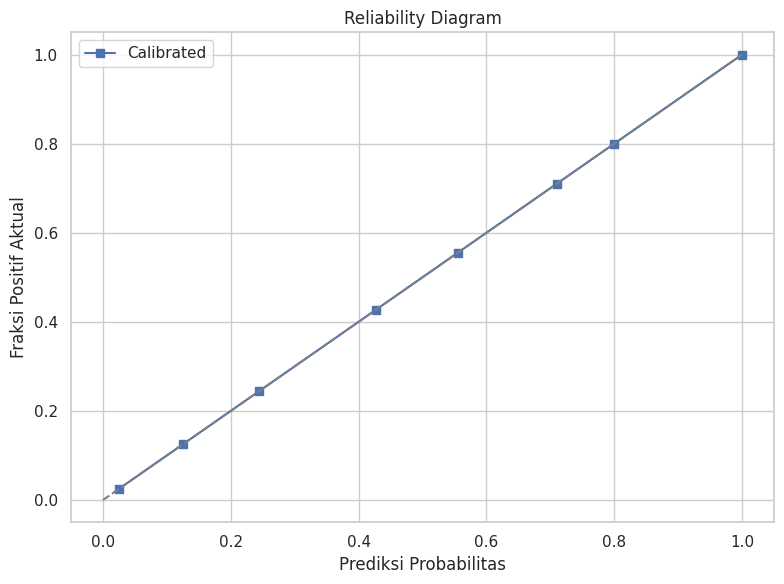

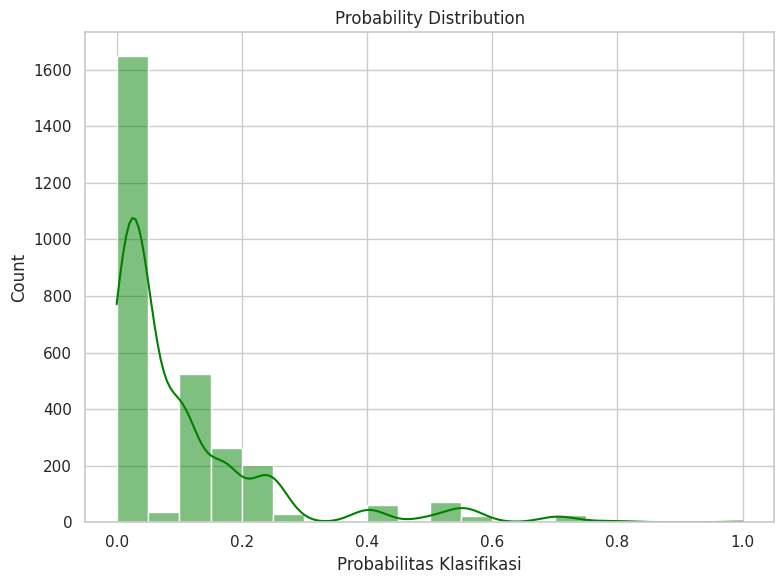

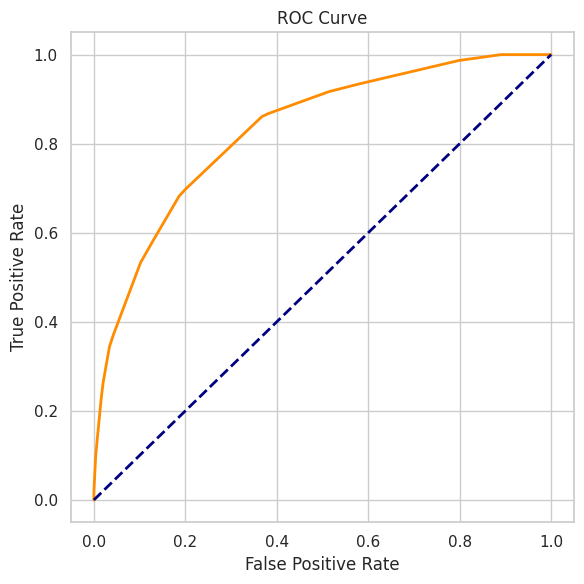

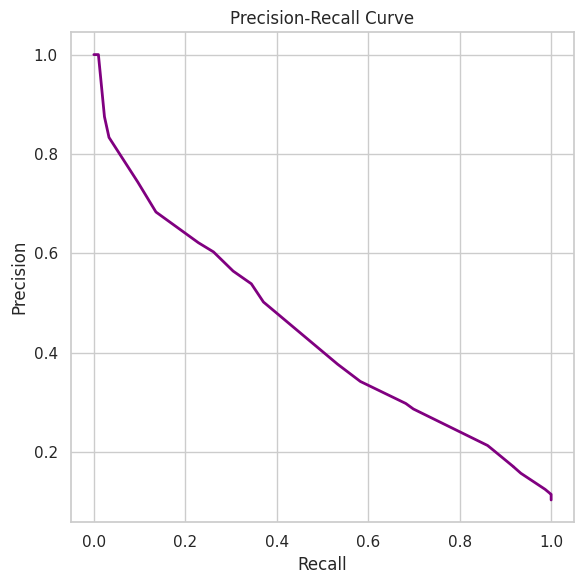

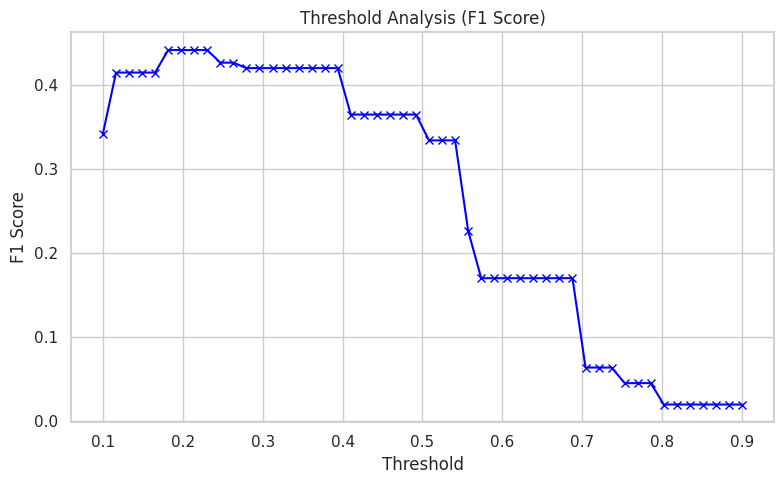

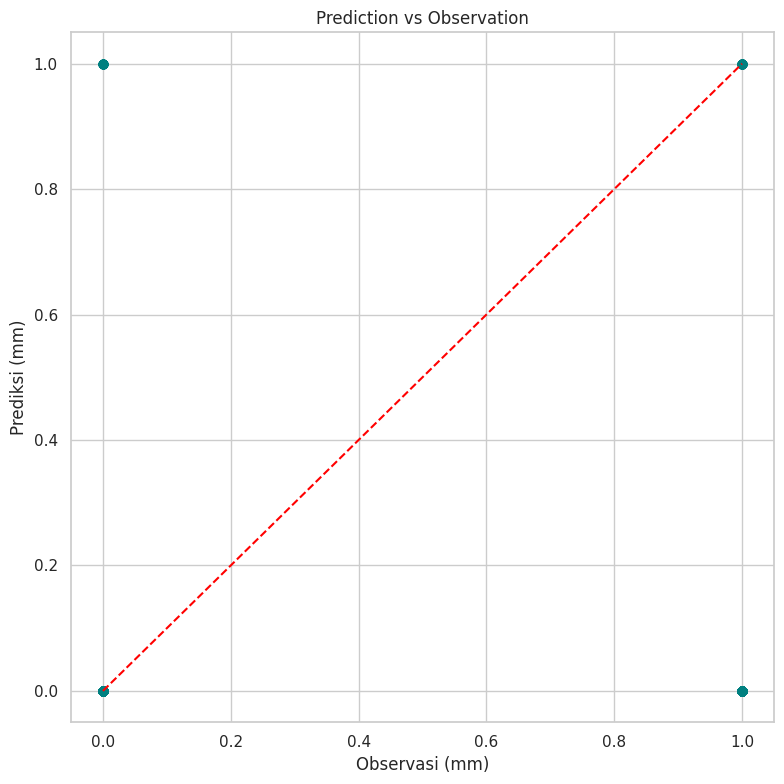

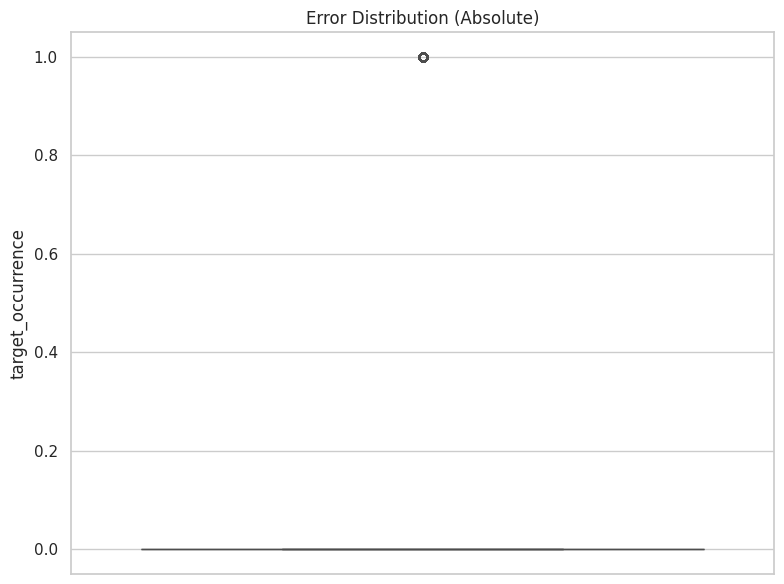

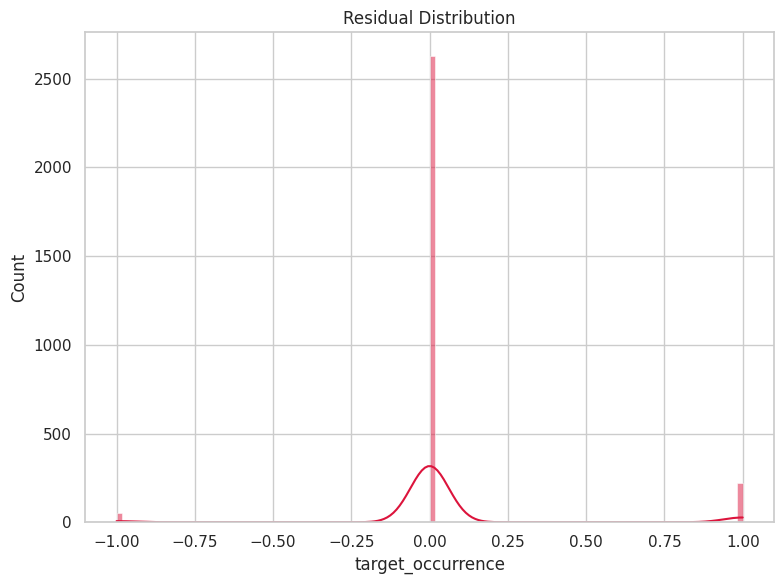

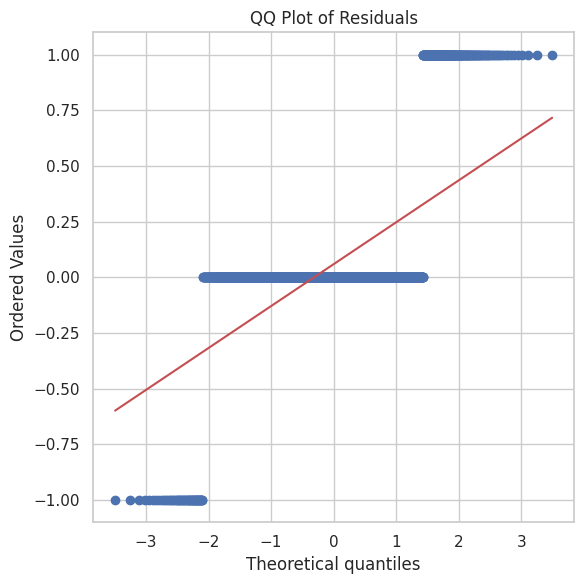

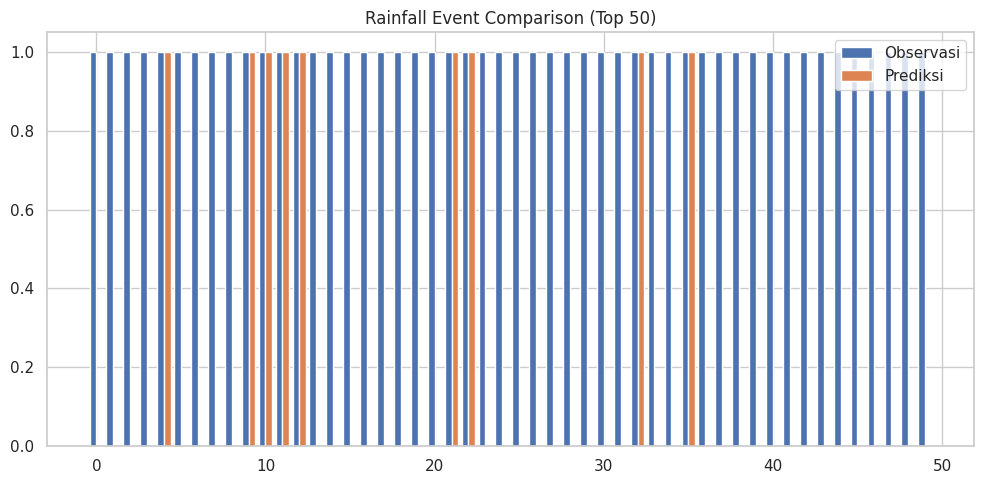

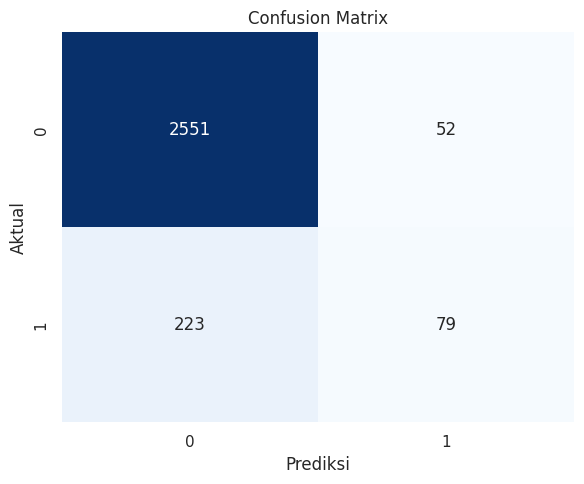

2026-07-01 14:18:15,338 - INFO - Menghitung metrik regresi...


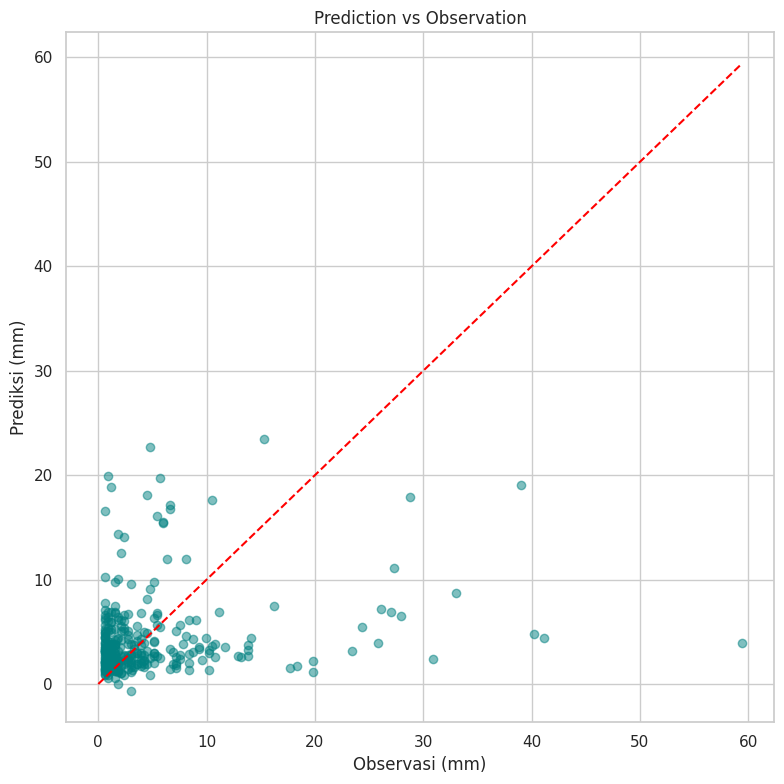

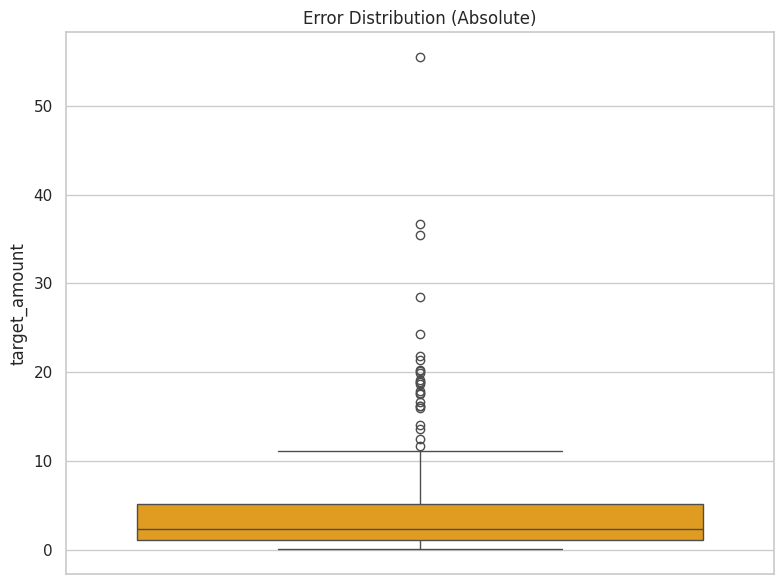

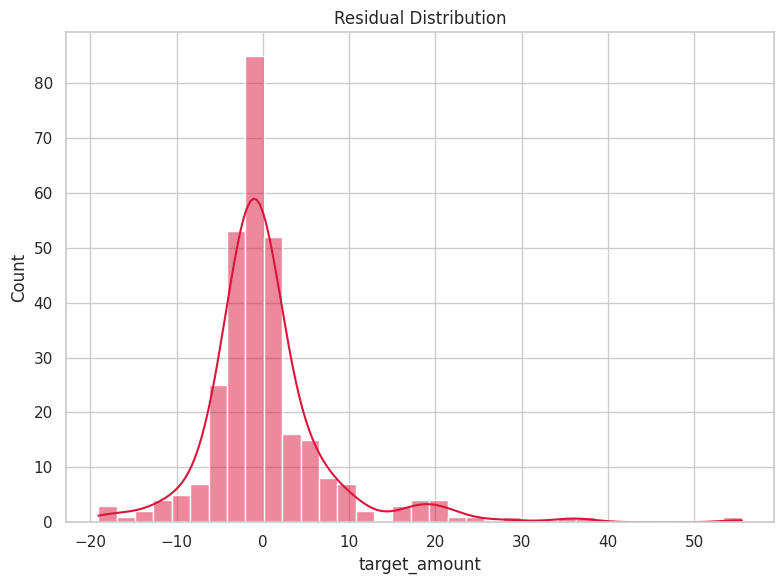

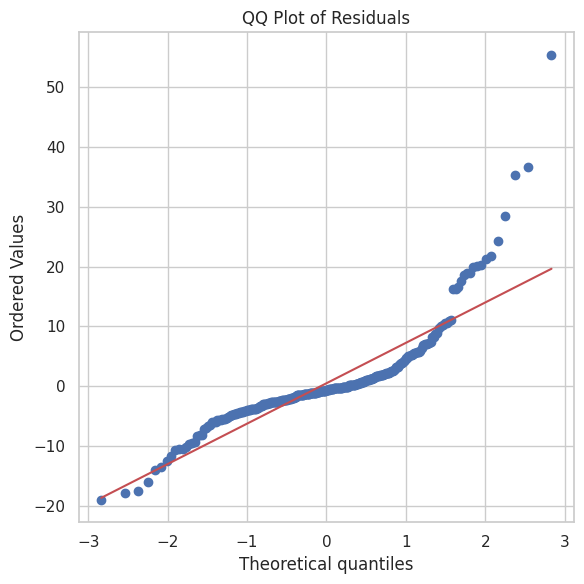

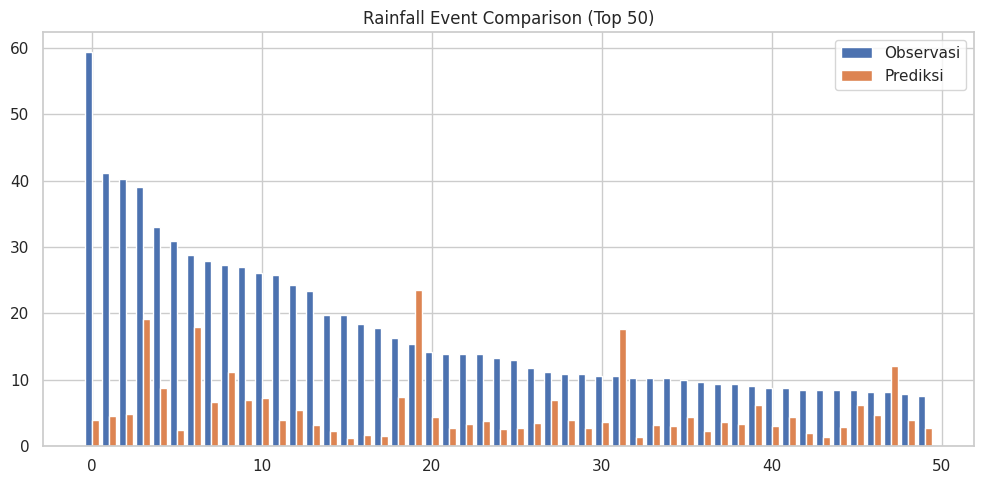

2026-07-01 14:18:16,812 - INFO - Membuat Plot Perbandingan Pre-Trained vs Fine-Tuned (XGBoost)...


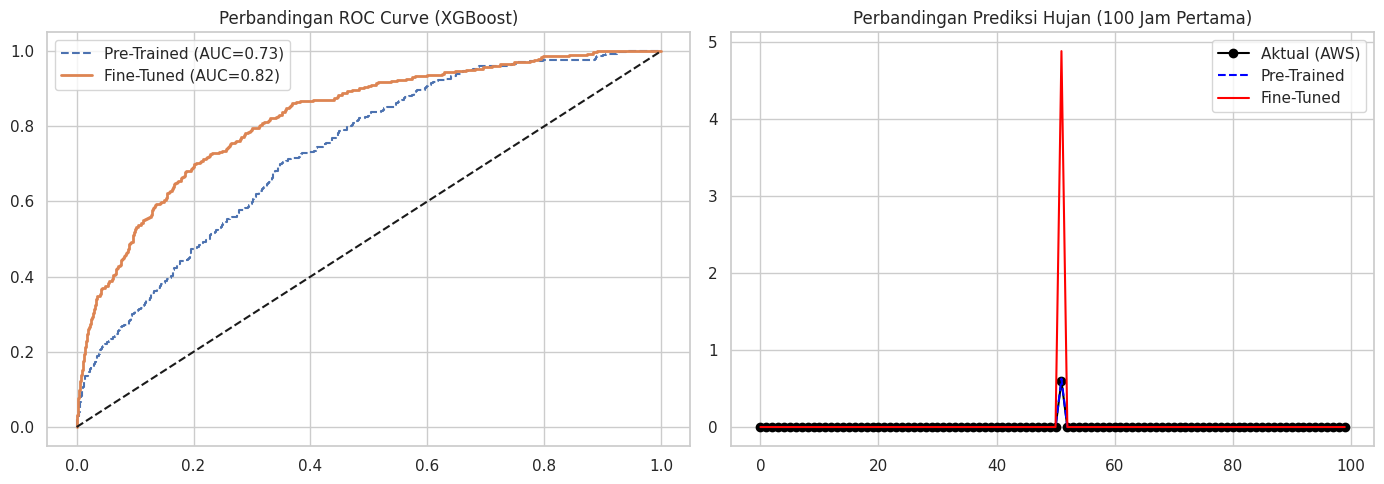

2026-07-01 14:18:17,313 - INFO - Unified XGBoost Pipeline Selesai!


In [12]:
# Sel 10: Proses Fine-Tuning & Perbandingan Model (XGBoost)
import xgboost as xgb
import joblib
from sklearn.isotonic import IsotonicRegression

# 1. EVALUASI BEFORE TUNING (Pre-trained Model)
logger.info("Mengevaluasi Model Pre-Trained XGBoost pada Data Test AWS...")
pre_test_probs = clf_best.predict_proba(X_test)[:, 1]
pre_test_preds = (pre_test_probs >= 0.5).astype(int)

pre_test_preds_r = np.zeros(len(y_test_occ))
rainy_te = y_test_occ == 1
if reg_best is not None and np.sum(rainy_te) > 0:
    pre_test_preds_r[rainy_te] = reg_best.predict(X_test[rainy_te])

# 2. PROSES FINE-TUNING (Warm-Start / Update dengan Data AWS 2025)
logger.info("Memulai Fine-Tuning XGBoost Classifier...")
import os
import json

# Gunakan model bawaan dari stage pre-training sebagai baseline
clf_best.set_params(learning_rate=0.01) # LR lebih kecil untuk fine-tuning
# Untuk XGBoost 2.0+, warm start secara native didukung dengan memberikan xgb_model di fit()
# Tapi cara aman adalah dengan melatih manual pakai xgb.train
dtrain = xgb.DMatrix(X_train, label=y_train_occ)
dval = xgb.DMatrix(X_val, label=y_val_occ)

# Dapatkan parameter model sebelumnya dan latih lagi
clf_params = clf_best.get_params()
booster = clf_best.get_booster()
clf_finetuned_booster = xgb.train(
    params=clf_params,
    dtrain=dtrain,
    num_boost_round=100,
    evals=[(dval, 'val')],
    xgb_model=booster,
    verbose_eval=False
)
clf_best._Booster = clf_finetuned_booster
joblib.dump(clf_best, evaluator.dirs['models_clf'] / 'best_xgb_occ_finetuned.pkl')

# Calibrator Re-fit
iso_reg = IsotonicRegression(out_of_bounds='clip')
val_probs_uncal = clf_best.predict_proba(X_val)[:, 1]
iso_reg.fit(val_probs_uncal, y_val_occ)
joblib.dump(iso_reg, evaluator.dirs['models_cal'] / 'isotonic_calibrator_finetuned.pkl')

rainy_mask_train = y_train_occ == 1
rainy_mask_val = y_val_occ == 1

if np.sum(rainy_mask_train) > 10 and reg_best is not None:
    logger.info("Memulai Fine-Tuning XGBoost Regressor...")
    X_train_r, y_train_r = X_train[rainy_mask_train], y_train_reg[rainy_mask_train]
    X_val_r, y_val_r = X_val[rainy_mask_val], y_val_reg[rainy_mask_val]
    
    dtrain_r = xgb.DMatrix(X_train_r, label=y_train_r)
    dval_r = xgb.DMatrix(X_val_r, label=y_val_r)
    
    reg_params = reg_best.get_params()
    reg_booster = reg_best.get_booster()
    reg_finetuned_booster = xgb.train(
        params=reg_params,
        dtrain=dtrain_r,
        num_boost_round=100,
        evals=[(dval_r, 'val')],
        xgb_model=reg_booster,
        verbose_eval=False
    )
    reg_best._Booster = reg_finetuned_booster
    joblib.dump(reg_best, evaluator.dirs['models_reg'] / 'best_xgb_reg_finetuned.pkl')
    
# 3. EVALUASI AFTER TUNING
test_probs_uncal = clf_best.predict_proba(X_test)[:, 1]
test_probs_cal = iso_reg.predict(test_probs_uncal)
test_preds_occ = (test_probs_cal >= 0.5).astype(int)

clf_metrics, meteo_metrics = evaluator.evaluate_classification(y_test_occ, test_probs_uncal, test_probs_cal, test_preds_occ)
evaluator.plot_confusion_matrix(y_test_occ, test_preds_occ)

test_preds_r = np.zeros(len(y_test_occ))
if reg_best is not None and np.sum(rainy_te) > 0:
    test_preds_r[rainy_te] = reg_best.predict(X_test[rainy_te])
    reg_metrics = evaluator.evaluate_regression(y_test_reg[rainy_te], test_preds_r[rainy_te])

# 4. PLOTTING PERBANDINGAN (Before vs After)
logger.info("Membuat Plot Perbandingan Pre-Trained vs Fine-Tuned (XGBoost)...")
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Classification ROC Before vs After
from sklearn.metrics import roc_curve, auc
fpr_pre, tpr_pre, _ = roc_curve(y_test_occ, pre_test_probs)
fpr_post, tpr_post, _ = roc_curve(y_test_occ, test_probs_uncal)

ax[0].plot(fpr_pre, tpr_pre, label=f'Pre-Trained (AUC={auc(fpr_pre, tpr_pre):.2f})', linestyle='--')
ax[0].plot(fpr_post, tpr_post, label=f'Fine-Tuned (AUC={auc(fpr_post, tpr_post):.2f})', linewidth=2)
ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_title('Perbandingan ROC Curve (XGBoost)')
ax[0].legend()

# Timeseries Before vs After (100 Jam Pertama)
test_mask_arr = np.where(test_mask)[0]
start_idx = 0
end_idx = min(100, len(y_test_reg))

ax[1].plot(y_test_reg.values[start_idx:end_idx], label='Aktual (AWS)', color='black', marker='o')
ax[1].plot(pre_test_preds_r[start_idx:end_idx], label='Pre-Trained', color='blue', linestyle='--')
ax[1].plot(test_preds_r[start_idx:end_idx], label='Fine-Tuned', color='red', linestyle='-')
ax[1].set_title('Perbandingan Prediksi Hujan (100 Jam Pertama)')
ax[1].legend()

plt.tight_layout()
plt.savefig(evaluator.dirs['plots'] / 'finetuning_comparison_xgb.png')
plt.show()

evaluator.generate_report(len(X_train), len(X_val), len(X_test), X.columns.tolist(), clf_metrics, meteo_metrics, reg_metrics, "XGBoost (Fine-Tuned)")
logger.info("Unified XGBoost Pipeline Selesai!")


## Analisis SHAP (*Feature Importance*)

Menghasilkan visualisasi *Game Theory* (SHAP) untuk membongkar kotak hitam (*blackbox*) model. Grafik ini menunjukkan **variabel mana yang paling kuat pengaruhnya** (misal: *CAPE* atau *Kelembaban*) dalam memicu prediksi hujan lebat.

2026-07-01 14:18:17,399 - INFO - Membangkitkan plot SHAP untuk Model XGBoost...


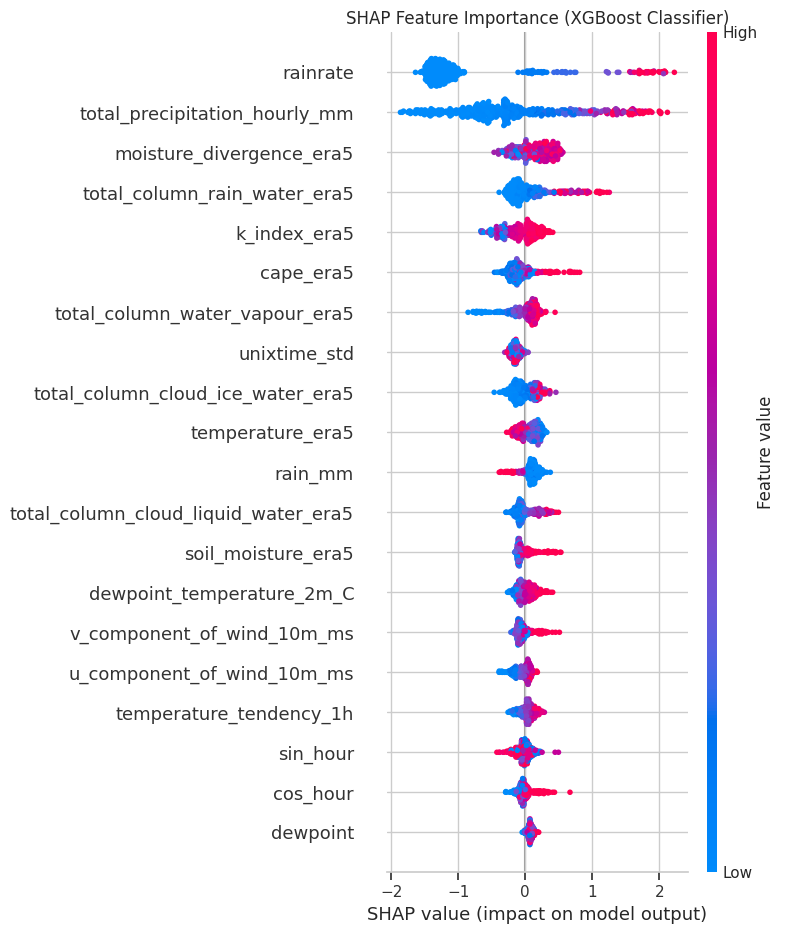

2026-07-01 14:18:23,916 - INFO - Plot SHAP berhasil disimpan!


In [13]:
# Sel Terakhir: Analisis SHAP (Feature Importance)
import shap
import matplotlib.pyplot as plt

logger.info("Membangkitkan plot SHAP untuk Model XGBoost...")

# Gunakan TreeExplainer yang sangat cepat untuk XGBoost
explainer = shap.TreeExplainer(clf_best)
# Ambil sampel dari Test Set untuk efisiensi
X_shap = X_test.sample(n=min(500, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, show=False)
plt.title('SHAP Feature Importance (XGBoost Classifier)')
plt.tight_layout()
plt.savefig(evaluator.dirs['plots'] / 'shap_summary_clf.png')
plt.show()

logger.info("Plot SHAP berhasil disimpan!")
